In [1]:
# Load Dataset
import pandas as pd

df = pd.read_csv("Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [4]:
# Convert Date Columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [7]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [9]:
# Create Year, Month, and Day columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [11]:
# Remove Invalid Records
df = df[df['Sales'] > 0]
df = df[df['Units'] > 0]

In [13]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
Year              0
Month             0
Day               0
dtype: int64

# Create Profitability Metrics

In [16]:
# Gross Margin
df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100
df["Gross Margin %"]

0        64.923077
1        65.333333
2        71.346705
3        69.444444
4        65.333333
           ...    
10189    64.923077
10190    71.346705
10191    69.444444
10192    65.333333
10193    69.444444
Name: Gross Margin %, Length: 10194, dtype: float64

In [18]:
# Profit per Unit
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]
df["Profit per Unit"]

0        2.11
1        2.45
2        2.49
3        2.50
4        2.45
         ... 
10189    2.11
10190    2.49
10191    2.50
10192    2.45
10193    2.50
Name: Profit per Unit, Length: 10194, dtype: float64

In [20]:
# Revenue Contribution
df["Revenue Contribution"] = df["Sales"] / df["Sales"].sum()
df["Revenue Contribution"]

0        0.000046
1        0.000053
2        0.000074
3        0.000076
4        0.000079
           ...   
10189    0.000069
10190    0.000049
10191    0.000076
10192    0.000185
10193    0.000076
Name: Revenue Contribution, Length: 10194, dtype: float64

In [22]:
# Profit Contribution
df["Profit Contribution"] = df["Gross Profit"] / df["Gross Profit"].sum()
df["Profit Contribution"]

0        0.000045
1        0.000052
2        0.000080
3        0.000080
4        0.000079
           ...   
10189    0.000068
10190    0.000053
10191    0.000080
10192    0.000184
10193    0.000080
Name: Profit Contribution, Length: 10194, dtype: float64

# Product Level Analysis

In [25]:
product = df.groupby("Product Name").agg(
    Sales=("Sales","sum"),
    Profit=("Gross Profit","sum"),
    Units=("Units","sum")
).reset_index()

product["Margin %"] = (product["Profit"] / product["Sales"]) * 100

product.sort_values("Profit", ascending=False).head(10)

,Product Name,Sales,Profit,Units,Margin %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000
14,Wonka Gum,597.50,310.70,478,52.000000
0,Everlasting Gobstopper,130.00,104.00,13,80.000000
4,Kazookles,1205.75,92.75,371,7.692308
3,Hair Toffee,76.50,59.50,17,77.777778


# Division Performance

In [28]:
# Analyze Chocolate vs Sugar vs Other.
division = df.groupby("Division").agg(
    Sales=("Sales","sum"),
    Profit=("Gross Profit","sum")
).reset_index()

division["Margin %"] = (division["Profit"] / division["Sales"]) * 100

division

,Division,Sales,Profit,Margin %
0,Chocolate,131692.90,88824.62,67.448298
1,Other,9663.25,4333.45,44.844643
2,Sugar,427.48,284.73,66.606625


Pareto Analysis (80/20 Rule)

In [31]:
# Goal: Find products generating 80% of profit.
pareto = product.sort_values(by="Profit", ascending=False)

pareto["Cumulative Profit %"] = (
    pareto["Profit"].cumsum() / pareto["Profit"].sum()
) * 100

In [33]:
pareto

,Product Name,Sales,Profit,Units,Margin %,Cumulative Profit %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,77.299717
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,95.057747
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,99.263528
14,Wonka Gum,597.50,310.70,478,52.000000,99.596031
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,99.707329
4,Kazookles,1205.75,92.75,371,7.692308,99.806588
3,Hair Toffee,76.50,59.50,17,77.777778,99.870263


# Cost vs Sales Diagnostics

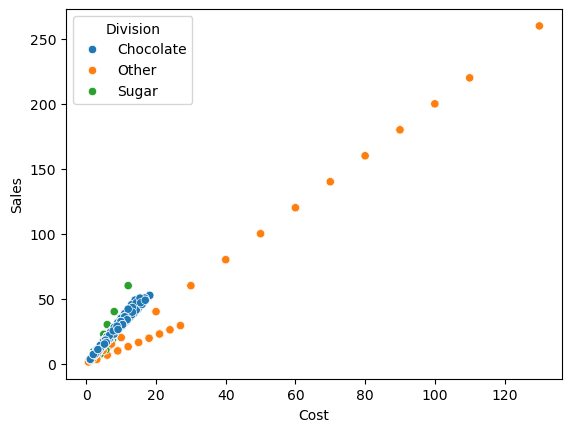

In [36]:
# Plot scatter.
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Cost", y="Sales", hue="Division")

plt.show()

# Visualizations

In [38]:
# Top 10 Products
product.sort_values("Profit", ascending=False).head(10)

,Product Name,Sales,Profit,Units,Margin %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000
14,Wonka Gum,597.50,310.70,478,52.000000
0,Everlasting Gobstopper,130.00,104.00,13,80.000000
4,Kazookles,1205.75,92.75,371,7.692308
3,Hair Toffee,76.50,59.50,17,77.777778


<Axes: xlabel='Division', ylabel='Sales'>

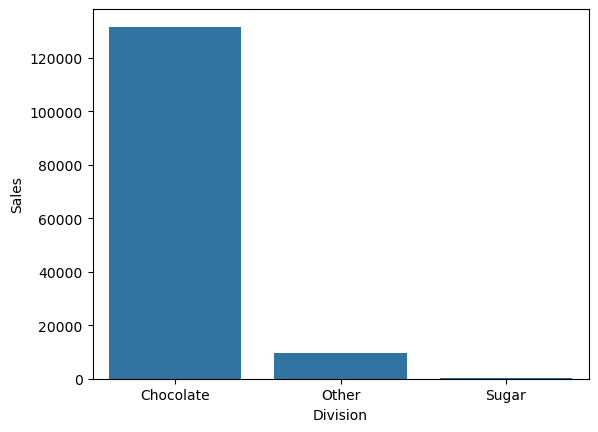

In [39]:
# Division Revenue vs Profit
sns.barplot(data=division, x="Division", y="Sales")

<Axes: xlabel='Division', ylabel='Gross Margin %'>

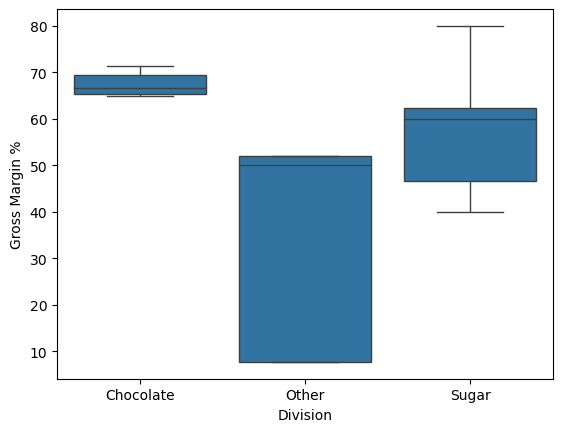

In [40]:
# Margin Distribution
sns.boxplot(data=df, x="Division", y="Gross Margin %")

# Streamlit Dashboard

In [46]:
import streamlit as st
import pandas as pd

df = pd.read_csv("Nassau Candy Distributor.csv")

st.title("Nassau Candy Profitability Dashboard")

division = st.sidebar.selectbox(
    "Select Division",
    df["Division"].unique()
)

filtered = df[df["Division"] == division]

st.write(filtered.head())

2026-03-24 21:22:44.075 
  command:

    streamlit run C:\Users\kunda\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-24 21:22:44.079 Session state does not function when running a script without `streamlit run`


In [50]:
# Add Charts
st.bar_chart(filtered.groupby("Product Name")["Gross Profit"].sum())

DeltaGenerator()

In [61]:
# After all your analysis (after page 9 work)

df.to_csv("Candy_Analysis.csv", index=False)
print("CSV file created successfully!")

CSV file created successfully!
